### This notebook steps through the fedverse PR1 pipeline
Author: William B. Rubio<br>
Based off code created by: Chantelle Murrell and Sebastian Alves<br>



In [16]:
# Ensure to reload local package at all times
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Import local fedverse 
import sys
sys.path.insert(0, "src")           # relative to the project root where the notebook runs
from fedverse.fedcore import core
from fedverse.fedassays import fedpr1

# Import libraries
import pandas as pd
import os
from pathlib import Path
import warnings

# for reloading packages
import importlib

In [20]:
### Declare Paths ### 
# PR1 FMR1
ROOT_PATH = Path(r"C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\FMR1\pr1")

# define the directory for the L1 zipped data
L1_PATH = Path(ROOT_PATH, "FMR1_007_PR1_L1.zip")

# define the path for the key file
# the key file should always be a xlsx
KEY_PATH = Path(ROOT_PATH, "FMR1_007_Key.xlsx")

In [21]:
### Upload files ###

# fed3 warns on duplicate timestamps, but for FED data this is expected
# and not meaningful — suppress it globally rather than logging per-file
warnings.filterwarnings(
    "ignore",
    message="Index has duplicate values.*",
    category=RuntimeWarning,
)


# Ingest L1 
# call to load lists and ingest the data from the l1 folder
fed_list, loaded_files, session_types = core.ingest_l1(L1_PATH)

# Create Meta Data Key
# upload key file
key_df, msg = core._read_key_from_upload(KEY_PATH)

# Build key dataframe
key_df2 = core.build_or_rematch_key_df(loaded_files, session_types, key_df, msg_hint = f"Key status: {msg}")


==> Beginning Ingest
  [ok] Ingest Complete - Loaded 46 files. Session types captured for all.
==> Reading in key file
  [ok] Done - Key loaded
==> Building key dataframe
  [ok] Key status: Key loaded from upload (FMR1_007_Key.xlsx). 'Mouse_ID' found.
  [ok] Merged key columns into Key_Df (46 rows, 27 cols).


In [22]:
### Create individual PR1 plots ###

saved_paths_indv = fedpr1.pr1_indv_plots(fed_list, key_df2, ROOT_PATH)

==> Creating individual PR1 Plots
  [ok] saved FMR1_007_207_62_indvPR1
  [ok] saved FMR1_007_220_7_indvPR1
  [ok] saved FMR1_007_212_88_indvPR1
  [ok] saved FMR1_007_212_89_indvPR1
  [ok] saved FMR1_007_211_82_indvPR1
  [ok] saved FMR1_007_211_84_indvPR1
  [ok] saved FMR1_007_217_58_indvPR1
  [ok] saved FMR1_007_216_73_indvPR1
  [ok] saved FMR1_007_210_79_indvPR1
  [ok] saved FMR1_007_221_47_indvPR1
  [ok] saved FMR1_007_221_51_indvPR1
  [ok] saved FMR1_007_221_50_indvPR1
  [ok] saved FMR1_007_213_39_indvPR1
  [ok] saved FMR1_007_214_98_indvPR1
  [ok] saved FMR1_007_218_77_indvPR1
  [ok] saved FMR1_007_215_1_indvPR1
  [ok] saved FMR1_007_214_94_indvPR1
  [ok] saved FMR1_007_220_11_indvPR1
  [ok] saved FMR1_007_219_23_indvPR1
  [ok] saved FMR1_007_215_5_indvPR1
  [ok] saved FMR1_007_222_18_indvPR1
  [ok] saved FMR1_007_219_29_indvPR1
  [ok] saved FMR1_007_217_55_indvPR1
  [ok] saved FMR1_007_219_27_indvPR1
  [ok] saved FMR1_007_217_52_indvPR1
  [ok] saved FMR1_007_221_48_indvPR1
  [ok] 

In [23]:
### prepare and create L3 ###

# Clean PR1 metadata
meta_cols, md = core.build_metakey(key_df2, assay = "bandit")

# Find ID columns
id_col, other_id = core.pick_match_method(md)

# compute PR metrics
pm = fedpr1.compute_pr_metrics(fed_list, md)

pm_md = core.attach_meta(pm, md, id_col)

# Build the l3
pm_l3 = core.output_l3(pm_md, id_col, other_id, meta_cols, ROOT_PATH, assay = "pr1", )



100%|██████████| 46/46 [00:00<00:00, 548.52it/s]
  [ok] First set of metrics calculated
  [preview] preview — 46 rows x 10 cols
                      count      mean       std       min       25%       50%       75%       max
    Left_Poke          46.0  3346.043  1265.475   886.000  2515.000  3288.500  3926.250  6726.000
    Right_Poke         46.0   617.630   228.009   201.000   462.750   623.500   810.750  1057.000
    Total_Pokes        46.0  3963.674  1431.173  1129.000  3115.000  3851.000  4814.250  7673.000
    Accuracy           46.0    83.935     4.223    75.969    81.030    84.604    86.890    93.408
    PokesPerPellet     46.0    16.897     6.095     6.801    13.078    16.286    19.604    39.148
    MedianBreakPoint   46.0    10.239     9.189     4.000     6.000     8.000     9.375    60.000
    MaxBreakPoint      46.0    47.978    15.244    18.000    38.250    45.000    55.000    87.000
    Numberofblocks     46.0    17.261     6.104     3.000    13.250    18.000    21.750 

In [24]:
### PR Groups ###

# Build groupings - essentailly a refined matadata key
mapped_df = core.build_group_selections(md)

# Attach the grouping dataframe to the metrics
pm_grps_df = core.merge_group_selections(pm_md, mapped_df)



==> Building group selection dataframe
  [ok] X-axis grouping (hierarchy): ['Genotype']
  [ok] Total unique files (X map): 46
  [table] table — 4 rows x 1 cols
           UniqueFiles
    Group             
    WT              16
    HET             12
    HOM             11
    HEMI             7
  [ok] Hue grouping: ['Sex']
  [ok] Total unique files (Hue map): 46
  [table] table — 2 rows x 1 cols
           UniqueFiles
    Group             
    F               30
    M               16
  [ok] Grouping dataframe built
==> Merging group df and metric df
  [ok] Group and Metric dataframe merged


In [25]:
### PR Plotting ###
# Melt the metric dataframe to long format
pm_long = core.melt_metric(pm_grps_df, assay = "pr1")

# Create variables to control aesthetics
x_checks, x_colors, ordered_x = core.define_aesthetics(pm_long)

# Actually create the bar plots 
barplot_paths = core._run_plots(pm_long, x_checks, x_colors, ordered_x, ROOT_PATH)

==> Melting L3 to long format
  [ok] Metric dataframe Melted
==> Defining Aesthetics for Plotting
  [ok] Aesthetics defined - x_checks: {'WT': Checkbox(value=True, description='WT', indent=False, layout=Layout(width='260px')), 'HEMI': Checkbox(value=True, description='HEMI', indent=False, layout=Layout(width='260px')), 'HET': Checkbox(value=True, description='HET', indent=False, layout=Layout(width='260px')), 'HOM': Checkbox(value=True, description='HOM', indent=False, layout=Layout(width='260px'))}
  [ok] Aesthetics defined - x_colors: {'WT': Text(value='#7ACAFF', layout=Layout(width='120px')), 'HEMI': Text(value='#FFB193', layout=Layout(width='120px')), 'HET': Text(value='#9BDF94', layout=Layout(width='120px')), 'HOM': Text(value='#D2ACD3', layout=Layout(width='120px'))}
  [ok] Aesthetics defined - ordered_x: ['WT', 'HEMI', 'HET', 'HOM']
==> Creating Metric Plots
  [ok] Showing X groups: ['WT', 'HEMI', 'HET', 'HOM']  |  reference for stars: WT
c:\Users\william.b\AppData\Local\anacond

  [warn] Stats table emtpy


[HEMI]
  alpha_mean = 15.4416, beta_mean = 2.2740
  Q_meanparams(P = alpha_mean): P = 15.4416, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 15.4481, Q = 45.7867

[HET]
  alpha_mean = 11.3001, beta_mean = 1.8976
  Q_meanparams(P = alpha_mean): P = 11.3001, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 11.2246, Q = 46.6810

[HOM]
  alpha_mean = 8.2616, beta_mean = 1.9932
  Q_meanparams(P = alpha_mean): P = 8.2616, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 8.1559, Q = 47.7099

[WT]
  alpha_mean = 9.1880, beta_mean = 1.8747
  Q_meanparams(P = alpha_mean): P = 9.1880, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 9.3522, Q = 48.2345



,Group,N_mice,alpha_mean,alpha_sem,beta_mean,beta_sem
0,HEMI,6,15.442,3.565,2.274,0.283
1,HET,12,11.300,1.442,1.898,0.072
2,HOM,11,8.262,0.553,1.993,0.192
3,WT,16,9.188,0.567,1.875,0.117


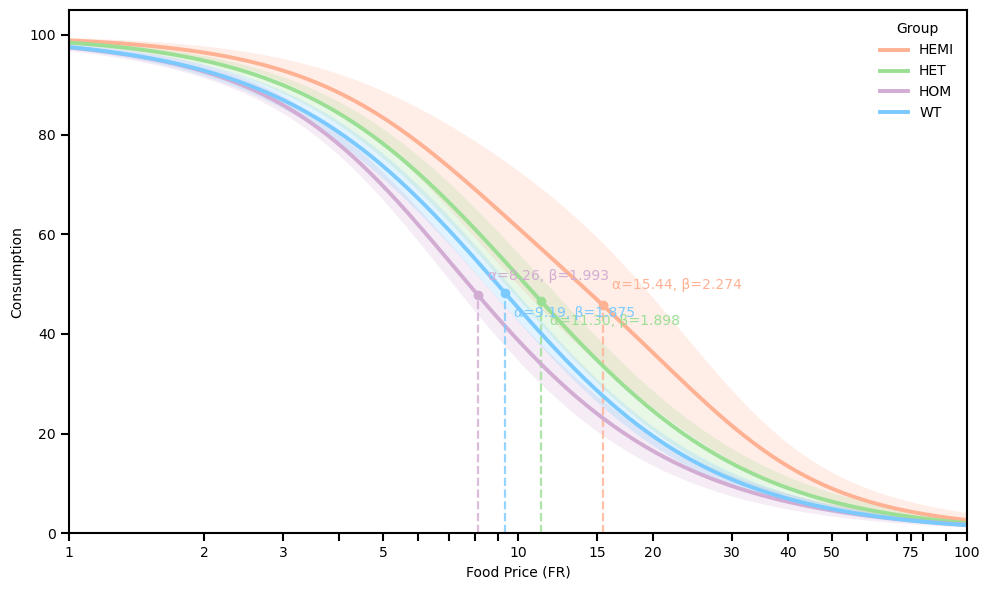

In [ ]:
### grouped demand curves ###

fig, stats = fedpr1.plot_group_mean_demand_with_params(mapped_df, pm_grps_df, md, x_colors)

In [26]:
### Final deliverables ###

# stats table
stats_df = core.build_stats_table(pm_long, ordered_x, ROOT_PATH, assay="pr1")

# L4
fedpr1.assemble_pr_l4(pm_long, x_colors, ordered_x, pm_md, ROOT_PATH, fed_list=fed_list, metadata_df=key_df2, bandittype = "100")

==> Building Stats Table
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\Users\william.b\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\william.

WindowsPath('C:/Users/william.b/Box/Kravitz Lab Box Drive/William/5_fed3_pipeline/TESTDIRDATA/FMR1/pr1/L4/FMR1_PR_L4.svg')

In [ ]:
### Call the pipeline ###


# Myt1l
root = Path(r"C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\MYT1L\pr1")
res = fedpr1.run_pr_l1_l4(root / "MYT1L_001_PR1_L1.zip",
                          root / "MYT1L_001_Key.xlsx", root)

# FMRI
root = Path(r"C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\FMR1\pr1")
res = fedpr1.run_pr_l1_l4(root / "FMR1_007_PR1_L1.zip",
                          root / "FMR1_007_Key.xlsx", root)

==> Beginning Ingest
  [ok] Ingest Complete - Loaded 39 files. Session types captured for all.
==> Reading in key file
  [ok] Done - Key loaded
==> Building key dataframe
  [ok] Key status: Key loaded from upload (MYT1L_001_Key.xlsx). 'Mouse_ID' found.
  [ok] Merged key columns into Key_Df (39 rows, 25 cols).
==> Creating individual PR1 Plots
  [ok] saved MYT1L_001_9_14_indvPR1
  [ok] saved MYT1L_001_5_24_indvPR1
  [ok] saved MYT1L_001_5_28_indvPR1
  [ok] saved MYT1L_001_2_5_indvPR1
  [ok] saved MYT1L_001_2_8_indvPR1
  [ok] saved MYT1L_001_9_12_indvPR1
  [ok] saved MYT1L_001_12_46_indvPR1
  [ok] saved MYT1L_001_12_51_indvPR1
  [ok] saved MYT1L_001_1_1_indvPR1
  [ok] saved MYT1L_001_5_23_indvPR1
  [ok] saved MYT1L_001_5_27_indvPR1
  [ok] saved MYT1L_001_1_4_indvPR1
  [ok] saved MYT1L_001_2_6_indvPR1
  [ok] saved MYT1L_001_9_11_indvPR1
  [ok] saved MYT1L_001_7_32_indvPR1
  [ok] saved MYT1L_001_8_41_indvPR1
  [ok] saved MYT1L_001_10_42_indvPR1
  [ok] saved MYT1L_001_12_48_indvPR1
  [ok] s

[HET]
  alpha_mean = 10.3860, beta_mean = 2.0082
  Q_meanparams(P = alpha_mean): P = 10.3860, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 10.2153, Q = 47.5974

[WT]
  alpha_mean = 12.1804, beta_mean = 1.9763
  Q_meanparams(P = alpha_mean): P = 12.1804, Q = 50.0000
  Q_meancurve (nearest alpha_mean): P = 12.2148, Q = 47.2681



,Group,N_mice,alpha_mean,alpha_sem,beta_mean,beta_sem
0,HET,19,10.386,0.953,2.008,0.085
1,WT,20,12.180,0.830,1.976,0.094


==> Building Stats Table
  [ok] Stats table built
==> Assembling PR1 L4 composite figure - testing
  [ok] L4 example mouse -> MYT1L_001_12_47
  [ok] PR1 L4 composite saved -> C:\Users\william.b\Box\Kravitz Lab Box Drive\William\5_fed3_pipeline\TESTDIRDATA\MYT1L\pr1\L4\MYT1L_PR_L4.svg
==> Beginning Ingest
  [ok] Ingest Complete - Loaded 46 files. Session types captured for all.
==> Reading in key file
  [ok] Done - Key loaded
==> Building key dataframe
  [ok] Key status: Key loaded from upload (FMR1_007_Key.xlsx). 'Mouse_ID' found.
  [ok] Merged key columns into Key_Df (46 rows, 27 cols).
==> Creating individual PR1 Plots
  [ok] saved FMR1_007_207_62_indvPR1
  [ok] saved FMR1_007_220_7_indvPR1
  [ok] saved FMR1_007_212_88_indvPR1
  [ok] saved FMR1_007_212_89_indvPR1
  [ok] saved FMR1_007_211_82_indvPR1
  [ok] saved FMR1_007_211_84_indvPR1
  [ok] saved FMR1_007_217_58_indvPR1
  [ok] saved FMR1_007_216_73_indvPR1
  [ok] saved FMR1_007_210_79_indvPR1
  [ok] saved FMR1_007_221_47_indvPR1
  